In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def plot(*args):
    count = len(args)
    fig, ax = plt.subplots(1,count)
    fig.set_figheight(5)
    fig.set_figwidth(15)
    if count==1:
        ax.imshow(args[0], cmap="gray")
    else:
        for i in range(len(ax)):
            ax[i].imshow(args[i], cmap="gray")
    plt.show()

In [2]:
image_i = cv2.imread("i.jpg", cv2.IMREAD_GRAYSCALE)
image_j = cv2.imread("j.jpg", cv2.IMREAD_GRAYSCALE)

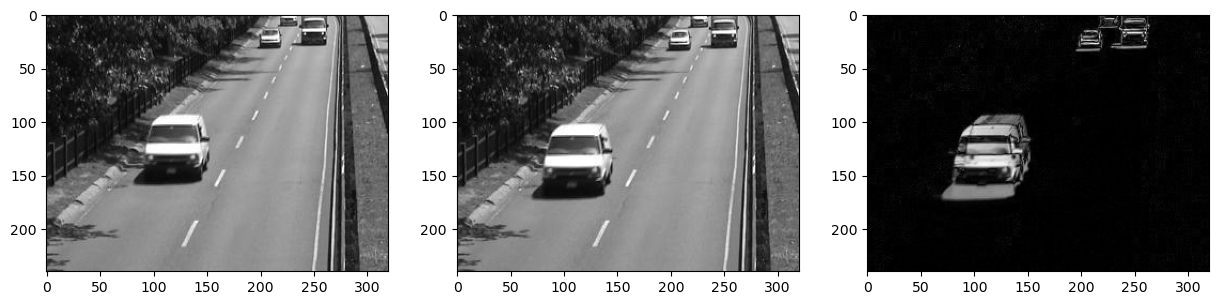

In [3]:
cp_1 = image_i.astype("int16")
cp_2 = image_j.astype("int16")
diff = np.abs(cp_1 - cp_2)

plot(image_i, image_j, diff)

In [30]:
s = 5
w = int(s/2)

dx, dy = 3, 3 

X,Y = image_i.shape

u,v = np.zeros((X,Y)), np.zeros((X,Y))

for y in range(w, Y - w):
    for x in range(w, X - w):
        frame_i = np.float32(image_i[x-w:x+w+1, y-w:y+w+1])
        min_distance = np.inf
        for i in range(-dx, dx+1):
            for j in range(-dy, dy+1):
                if i + x < w or i + x>= X - w or j + y < w or j + y >= Y-w:
                    pass
                else:
                    frame_j = np.float32(image_j[x+i-w:x+i+w+1, y+j-w:y+j+w+1])
                    distance = np.sqrt(np.sum(np.square(frame_i-frame_j)))
                    if distance < min_distance:
                        distance = min_distance
                        u[x,y] = x + i
                        v[x,y] = y + j



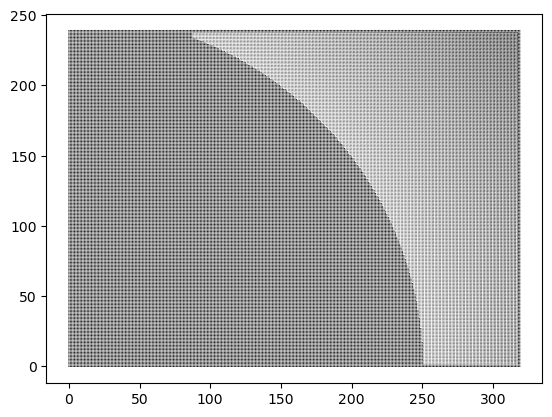

In [32]:
plt.quiver(u,v)
